0:	test: 0.7595886	best: 0.7595886 (0)	total: 83.4ms	remaining: 4m 10s
100:	test: 0.7758191	best: 0.7758775 (15)	total: 9.33s	remaining: 4m 27s
200:	test: 0.7764568	best: 0.7765418 (181)	total: 17.5s	remaining: 4m 3s
300:	test: 0.7763976	best: 0.7765418 (181)	total: 26.9s	remaining: 4m
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.7765418408
bestIteration = 181

Shrink model to first 182 iterations.

==================== CatBoost 报告 ====================
ROC-AUC Score: 0.7765
F1-Score:      0.6591

分类明细：
              precision    recall  f1-score   support

           0       0.72      0.81      0.76     11003
           1       0.72      0.61      0.66      8997

    accuracy                           0.72     20000
   macro avg       0.72      0.71      0.71     20000
weighted avg       0.72      0.72      0.71     20000



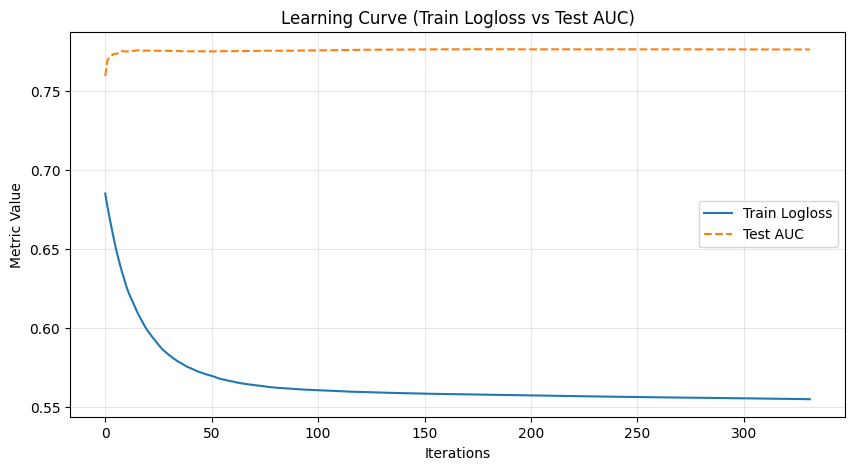

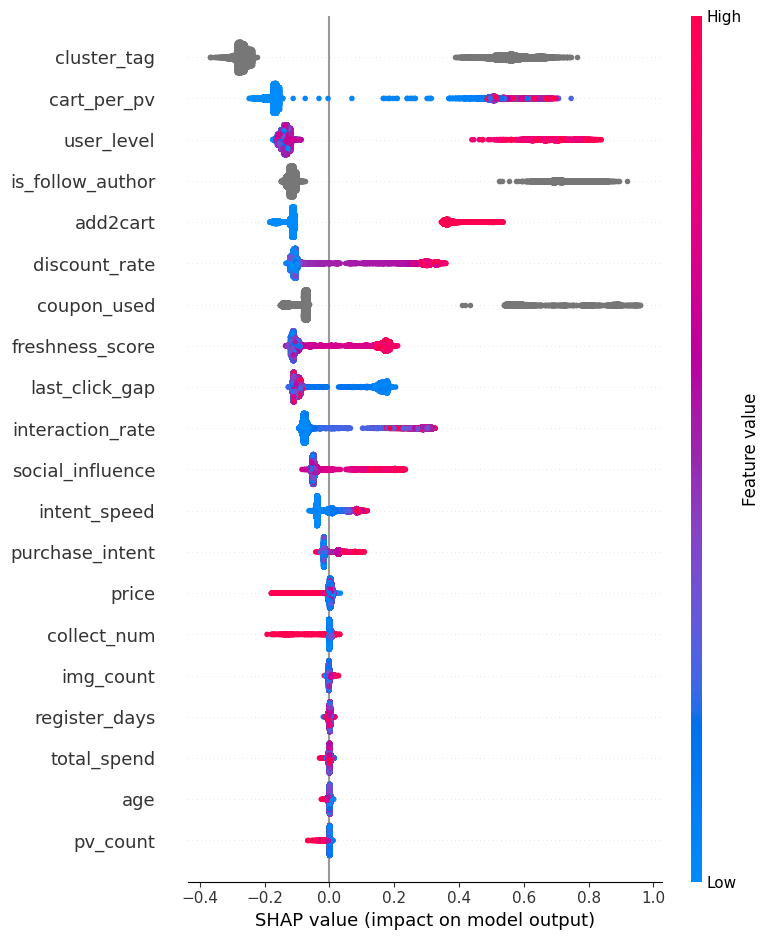

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool
import shap
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, f1_score

# 1. 加载数据
df = pd.read_csv('social_ecommerce_data.csv')

# 2. 特征工程
# 构造“意图纯度”指标，减少 add2cart 的噪声
df['cart_per_pv'] = df['add2cart'] / (df['pv_count'] + 1)
df['intent_speed'] = df['purchase_intent'] / (df['last_click_gap'] + 1)
df['is_impulse_buyer'] = ((df['add2cart'] > 0) & (df['last_click_gap'] < 2)).astype(int)

# 对长尾社交特征进行对数转换，使分布更平滑
log_features = ['total_spend', 'fans_num', 'follow_num', 'social_influence']
for col in log_features:
    df[col] = np.log1p(df[col])

# 3. BGMM 聚类
drop_cols = ['user_id', 'item_id', 'label']
X_temp = df.drop(columns=drop_cols)
numeric_cols = X_temp.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_temp[numeric_cols])

bgmm = BayesianGaussianMixture(
    n_components=8, # 减少组件数，增强聚类代表性
    weight_concentration_prior=0.01,
    covariance_type='diag',
    max_iter=300,
    random_state=42
)
df['cluster_tag'] = bgmm.fit_predict(X_scaled)

# 4. 准备训练数据
X = df.drop(columns=drop_cols)
y = df['label']

# 显式标记类别特征
cat_features = ['category', 'gender', 'is_follow_author', 'has_video',
                'coupon_received', 'coupon_used', 'cluster_tag', 'is_impulse_buyer']

for col in cat_features:
    X[col] = X[col].astype(str)

# 5. 数据集拆分 (分层抽样)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. CatBoost 模型初始化
model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=12,
    random_strength=1.5,
    bagging_temperature=1, # 开启贝叶斯采样
    eval_metric='AUC',
    early_stopping_rounds=150,
    verbose=100
)

# 7. 训练模型
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# 8. 综合评估
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("\n" + "="*20 + " CatBoost 报告 " + "="*20)
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"F1-Score:      {f1_score(y_test, y_pred):.4f}")
print("\n分类明细：")
print(classification_report(y_test, y_pred))

# 9. 绘制 Learning Curve
evals = model.get_evals_result()
plt.figure(figsize=(10, 5))
plt.plot(evals['learn']['Logloss'], label='Train Logloss')
plt.plot(evals['validation']['AUC'], label='Test AUC', linestyle='--')
plt.title('Learning Curve (Train Logloss vs Test AUC)')
plt.xlabel('Iterations')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 10. SHAP 分析
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test)